In [1]:
from freeflux import Model, Metabolite, Reaction
from mfa import replace_uptake_reaction, make_bounds, sample_fluxes, shuffle_labeling_pattern, get_mdv_dict, carb_exch, get_mdv_results_from_simulations, calc_net_fluxes, build_flux_ratios, calc_ratios_from_sims, plot_flux_ratios, sample_ratio_specific_fluxsets, get_flux_ratio, get_flux_ratio_wide, eval_RF_sim_pred, get_reconex_fluxes, get_mdv_results
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from scipy.io import loadmat
import numpy as np
from pathlib import Path
import warnings
# load read sumoflux data


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )

def expand_metabolite_name(name):
    """
    Expand a metabolite name like 'OAA14' into
    ['OAA14_m0', 'OAA14_m1', ..., 'OAA14_mN']
    where N = (d2 - d1) + 1
    """
    match = re.match(r"(.+?)(\d)(\d)$", name)
    if not match:
        raise ValueError(f"Unexpected metabolite format: {name}")

    base, d1, d2 = match.groups()
    d1, d2 = int(d1), int(d2)

    n = (d2 - d1) + 2
    return [f"{name}_m{i}" for i in range(n)]


def matmdvs_to_pd(path_to_mat):
    
    mat = loadmat(path_to_mat)
    
    colnames = [
        x[0] for x in mat["experimentalStrains"].ravel()
    ]

    rownames = [
        x[0] for x in mat["metabolites_measured"].ravel()
    ]
    
    expanded_rownames = []
    for r in rownames:
        expanded_rownames.extend(expand_metabolite_name(r))

    # rename OGA (oxoglutaric acid) to AKG (alpha-ketoglutarate) --> more canonical
    
    expanded_rownames = [re.sub("OGA", "AKG", x) for x in expanded_rownames]
    expanded_rownames = [re.sub("PYR", "Pyr", x) for x in expanded_rownames]

    data = pd.DataFrame(
        mat["experimentalData"], index = expanded_rownames, columns = colnames
    )    
    
    return(data)


def get_reconex_fluxes_test(fluxes, multiplier, seed=42):
    rxs = fluxes.index

    reversible_mask = rxs.str.endswith(("_f", "_b"))
    reversible_rxs = rxs[reversible_mask].str.removesuffix(("_f", "_b")).unique()
    irreversible_rxs = rxs[~reversible_mask]

    net_fluxes = pd.DataFrame.from_dict(
        {r: fluxes.loc[r + "_f"] - fluxes.loc[r + "_b"] for r in reversible_rxs},
        orient="index",
    )

    rng = np.random.default_rng(seed)
    new_xchg = net_fluxes.apply(
        lambda x: np.sign(x) * rng.uniform(0, np.abs(x*multiplier)), axis=1
    )

    return pd.concat(
        [
            (net_fluxes + new_xchg)
            .where(net_fluxes > 0, -new_xchg)
            .rename(index=lambda x: x + "_f"),
            new_xchg.where(net_fluxes > 0, -(net_fluxes + new_xchg)).rename(
                index=lambda x: x + "_b"
            ),
            fluxes.loc[irreversible_rxs],
        ]
    ).reindex(rxs)

def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0) 


target_emus = {
    "G6P": [1,2,3,4,5,6],
    "Pyr": [1,2,3],
    "S7P": [1,2,3,4,5,6,7],
    "Cit": [1,2,3,4,5,6],
    "Suc": [1,2,3,4],
    "Fum": [1,2,3,4],
    "Gln": [1,2,3,4,5],
    "Arg": [1,2,3,4,5,6],
    "Thr": [1,2,3,4],
    "Met": [1,2,3,4,5],
    "Asp": [1,2,3,4],
    "Asn": [1,2,3,4],
    "Ser": [1,2,3],
    "Phe": [1,2,3,4,5,6,7,8,9],
    "Tyr": [1,2,3,4,5,6,7,8,9]
}

add_target_emus = {
    "Trp": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "AMP": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "ADN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "ADE": [1,2,3,4,5],
    "dADN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}




Glc_100_U13C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [1], 
    purity = [0.994]    
)


flux_ratios_dict_Buni = {
    "glycolysis_PPP": (["pgi"], ["pgi", "g6pdh"]),
    "PEP_from_OAA": (["pyc"], ["pyc", "eno"]), 
    "Pyr_from_PEP": (["pk"], ["pk", "me", "oad", "pdh"]), 
    "OAA_from_PEP": (["pyc"], ["pyc", "mdh", "pc"]), 
    "AKG_from_Suc": (["kdh"], ["kdh", "icd"]), 
    "Mal_from_Fum": (["fum"], ["fum", "mdh", "me"]), 
    "OAA_from_Mal": (["mdh"], ["mdh", "pyc", "pc"]), 
    "Pyr_from_Mal": (["me"], ["me", "oad", "pk"]), 
    "Suc_from_Fum": (["sdh"], ["sdh", "suc"]), 
    "Pyr_from_AcCoA": (["pdh"],["pdh", "oad", "pk", "me"]), 
    "Mal_from_OAA": (["mdh"],["mdh", "fum", "me"]),
    
    "Pyr_from_OAA": (["oad"], ["oad", "pk", "me", "pdh"]), # species specific
    "Mal_from_Pyr": (["me"], ["me", "mdh", "fum"])
    
}



## Build B.uniformis model

In [2]:
buniformis_model_file = "../Config/Models/Buniformis/Buniformis_individualBiomass_nucleosides_with_RIBbm_ADN.tsv"
buniformis_model = Model("Buniformis")
buniformis_model.read_from_file(buniformis_model_file)

stoic_mat = buniformis_model.get_total_stoichiometric_matrix() 
lb, ub = make_bounds(stoic_mat, 0, 100, specific={
    "glk": [10, 10], 
    "co2in": [90,100],
    "co2out": [0,100]
})

## Plot flux distribution of B. uni in Adenosine co-feeding

In [3]:
fluxes_adn = pd.read_csv("../Output/CofeedBuni/adn_fluxes.csv", index_col = "reaction_id")


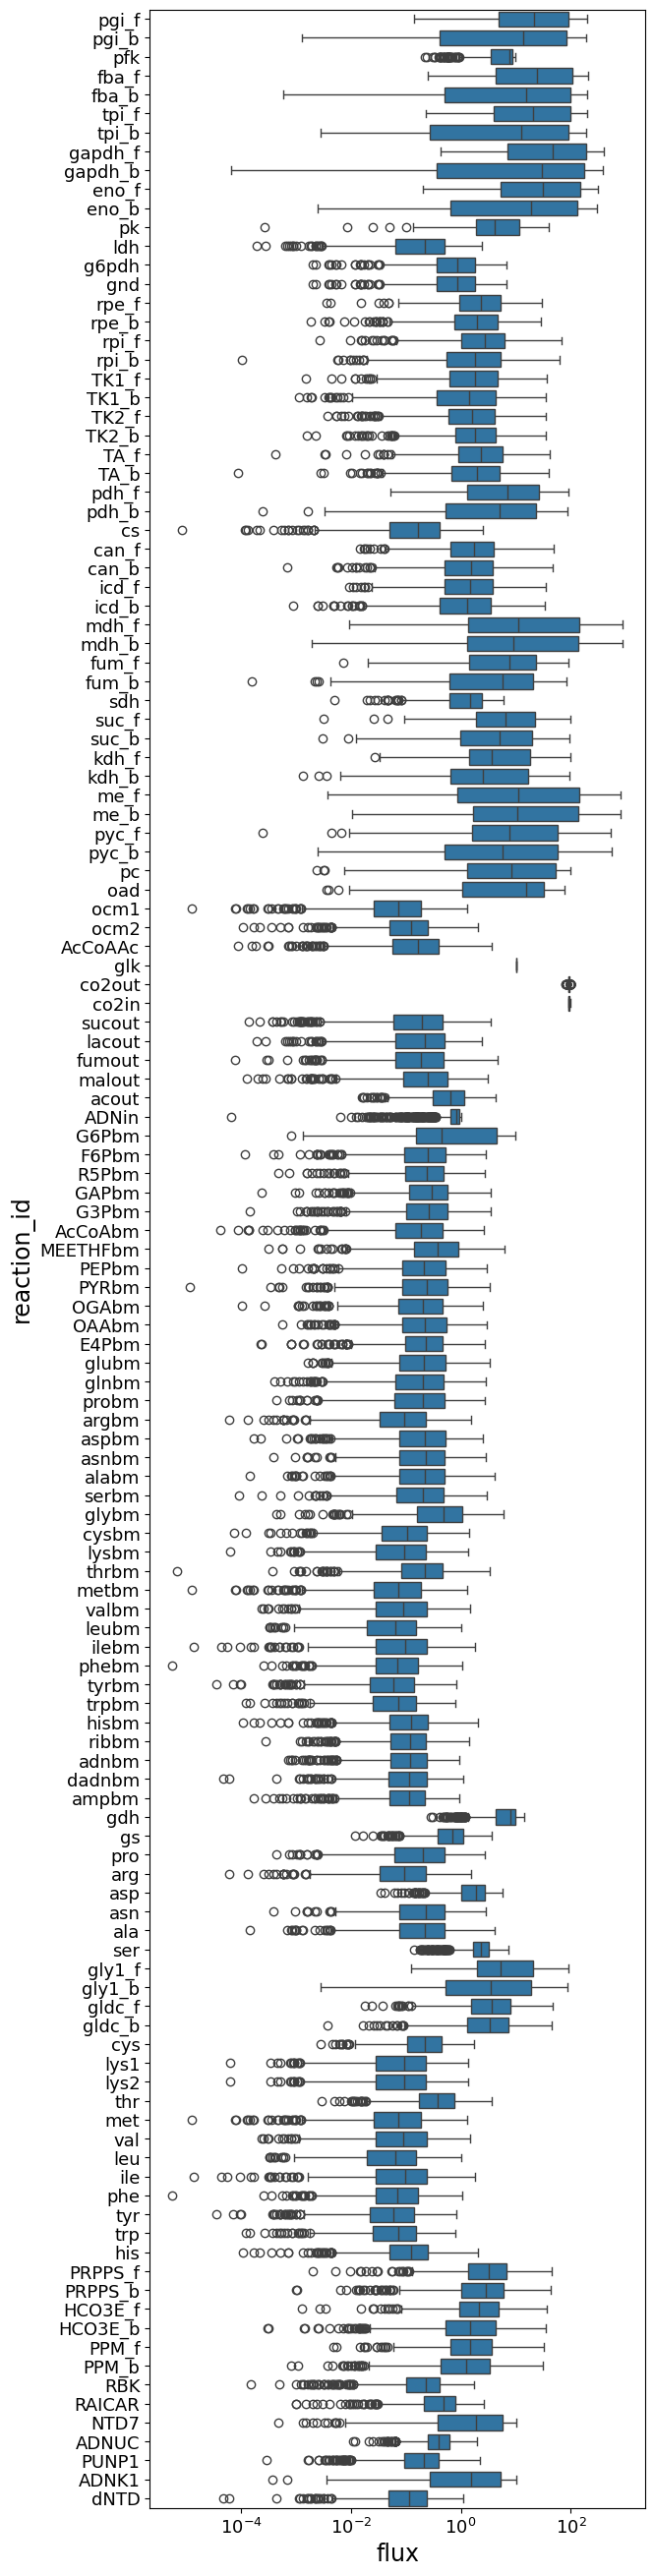

In [4]:

fig, ax = plt.subplots(figsize= (6.5, 33))
ax.set_xscale('log')
plt.setp(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis='both', labelsize=13)  
ax.xaxis.label.set_size(17)
ax.yaxis.label.set_size(17)
    

sns.boxplot(
    fluxes_adn
    .sample(n=1000, axis = 1, random_state = 87)
    .reset_index(names="reaction_id")
    .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux"),
    y="reaction_id", 
    x="flux", 
    ax=ax
)

fig.savefig('../Output/CofeedBuni/flux_distribution_Buni_ade.pdf', dpi = 300, bbox_inches = "tight")

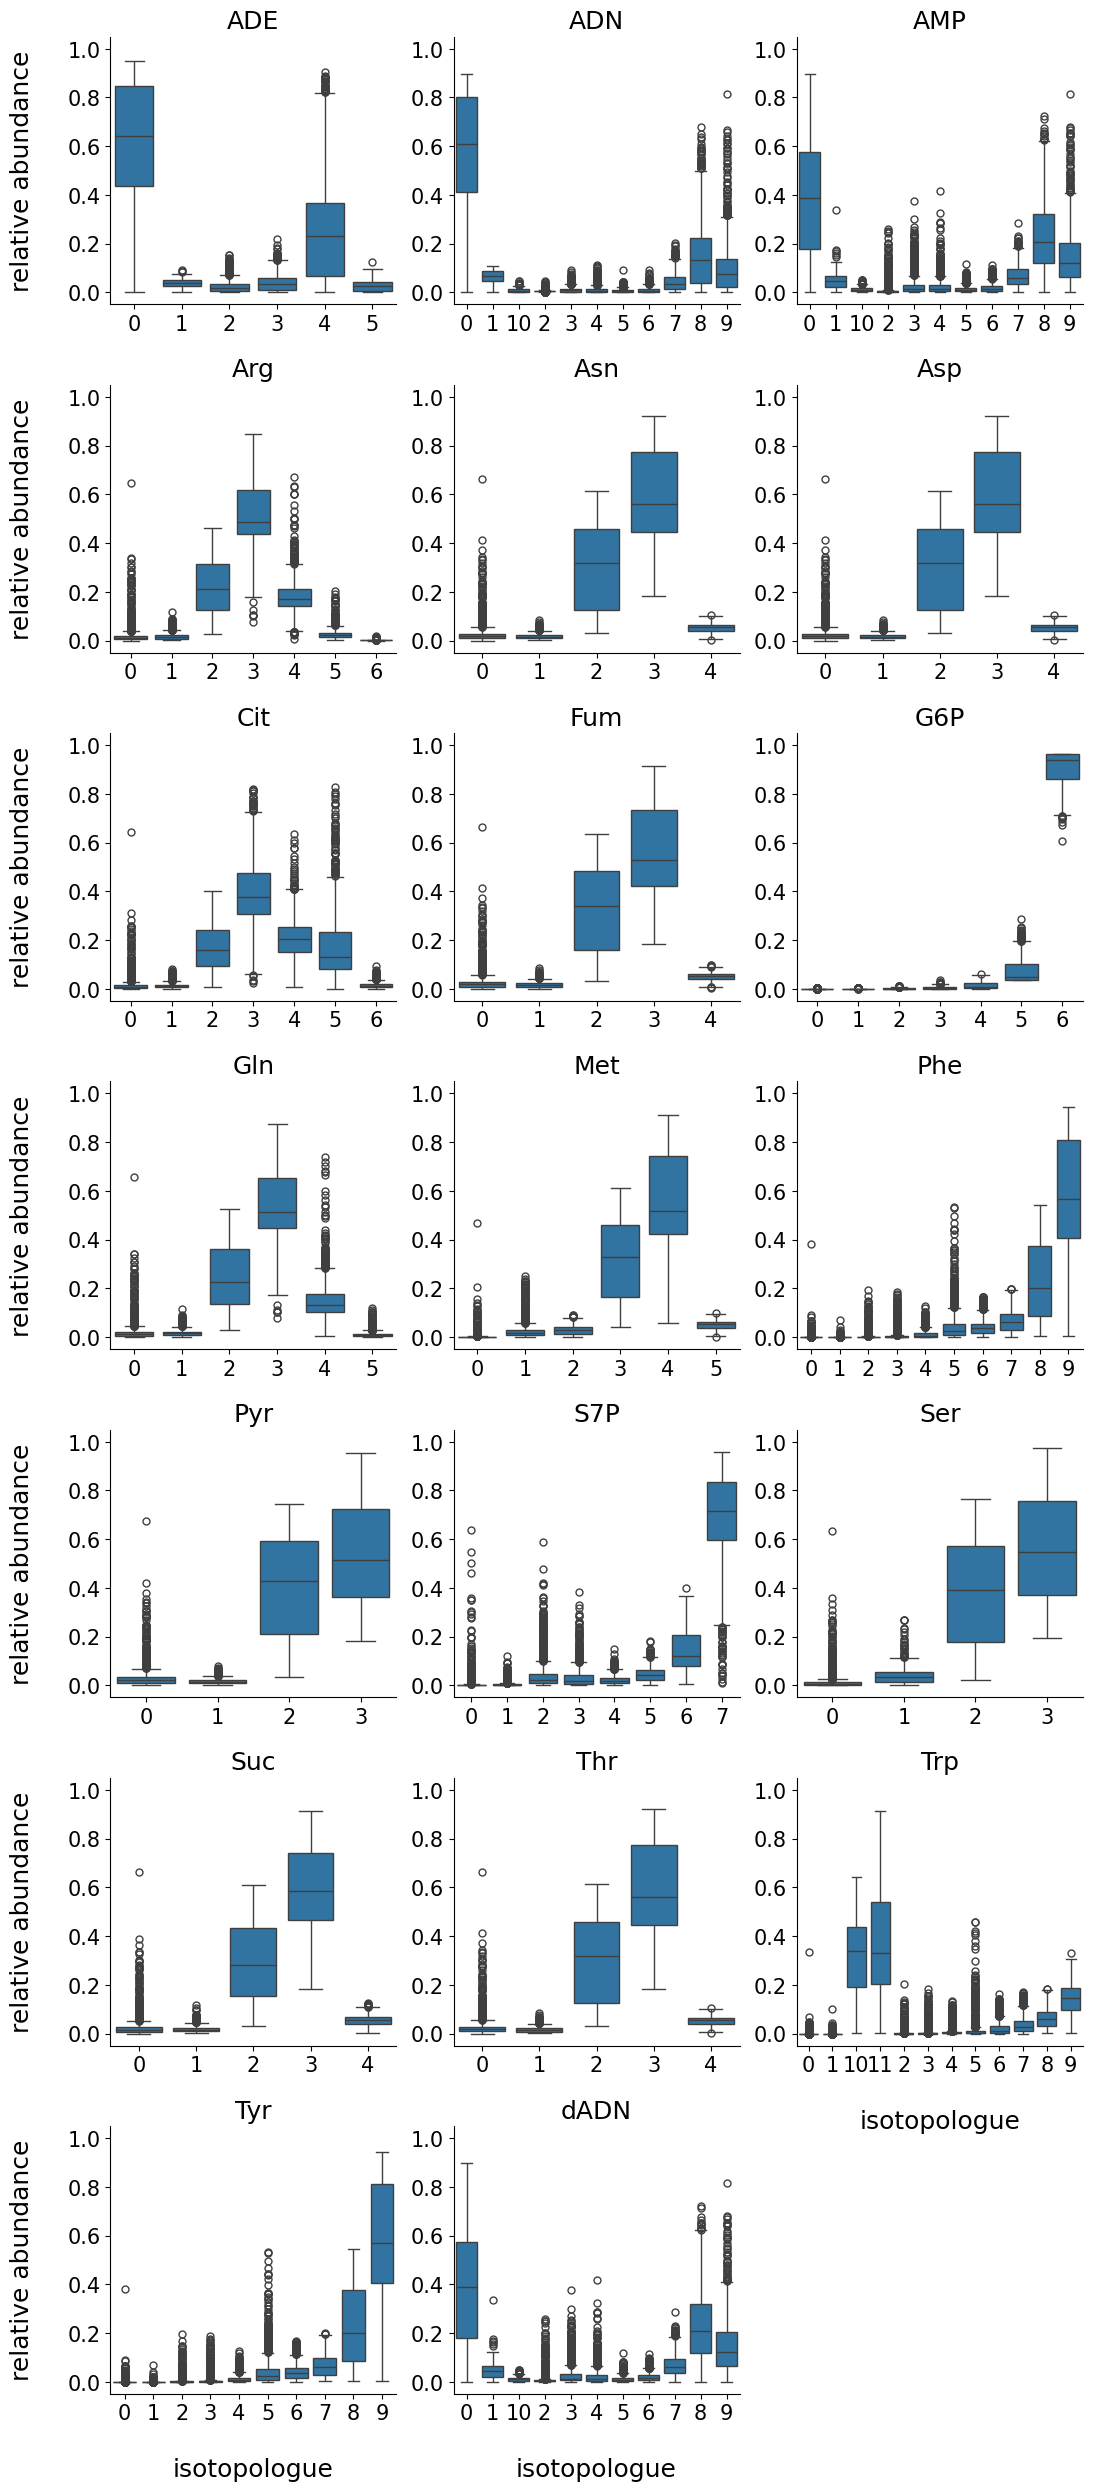

In [13]:

# Glc_100_U13C

mdvs_sub_10000 = get_mdv_results_from_simulations(buniformis_model, fluxes_adn.sample(n=1000, axis = 1, random_state = 87), target_emus | add_target_emus, Glc_100_U13C, parallel=8, as_df=True)
mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
df2 = mdvs_sub_10000_sorted.copy()
df2['subgroup'] = df2.index  # full name like Ala_123_1
df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore


# Melt to long fmormat (so each iteration becomes a row)
df_long2 = df2.melt(
    id_vars=['group', 'subgroup'],
    var_name='iteration',
    value_name='value'
)

df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]

df_long2.to_csv("../Output/CofeedBuni/Buniformis_individualBiomass_mdvs_1000_U13C_adn_cofeed.csv")

# make faceted boxplot

bxplt = sns.catplot(
    data = df_long2, 
    x = "subgroup",
    y = "value", 
    kind = "box", 
    col = "group", 
    sharex=False,
    sharey = False,
    col_wrap=3, 
    height = 3.5,
    aspect=1
    
)

bxplt.set_xticklabels(fontsize=15)
bxplt.set_axis_labels("isotopologue", "relative abundance", fontsize=18, labelpad=24)
bxplt.set_titles(template="{col_name}")
bxplt.figure.subplots_adjust(wspace=0.2, hspace=0.3)
bxplt.set(ylim=(-0.05, 1.05))

for ax in bxplt.axes.flat:
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15)
    ax.set_title(ax.get_title(), fontsize=18)



# bxplt.savefig('../Output/CofeedBuni/mdv_distribution_U13C.pdf')

## Plot flux ratio distributions from Adenosine cofeeding situation

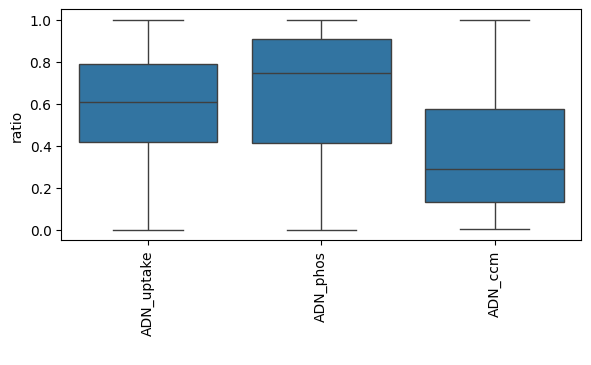

In [11]:
adn_flux_ratios_dict = {
    'ADN_uptake': [['ADNin'], ['RAICAR', 'ADNin']],
    'ADN_phos': [['ADNK1'], ['ADNK1', 'RAICAR']],
    "ADN_ccm": [["ADNUC", "PUNP1"], ["ADNUC", "PUNP1", "ADNK1", "adnbm"]]
}

flux_ratios = pd.concat([
        
        pd.concat([
            fluxes_adn
                .pipe(get_flux_ratio, *reac_ratio)
                .assign(flux_ratio_name=name) 
            for name, reac_ratio in adn_flux_ratios_dict.items()
        ], ignore_index=True).assign(comparison="hopsy")])


fig, ax = plt.subplots(figsize = (13, 3))
plt.setp(ax.get_xticklabels(), rotation=90)
fig.subplots_adjust(left=0.5)
ax.set(ylabel = "ratio", xlabel = " ")
sns.boxplot(
    flux_ratios,
    x="flux_ratio_name",
    y="flux_ratio",
    dodge=True, 
    ax = ax
)

fig.savefig("../Output/CofeedBuni/ratio_distribution.pdf", dpi = 300, bbox_inches = "tight")
